In [7]:
import dataset, features, modeling, plots
import pandas as pd

# Tworzenie modeli

Loaded merged data with 8 price fields


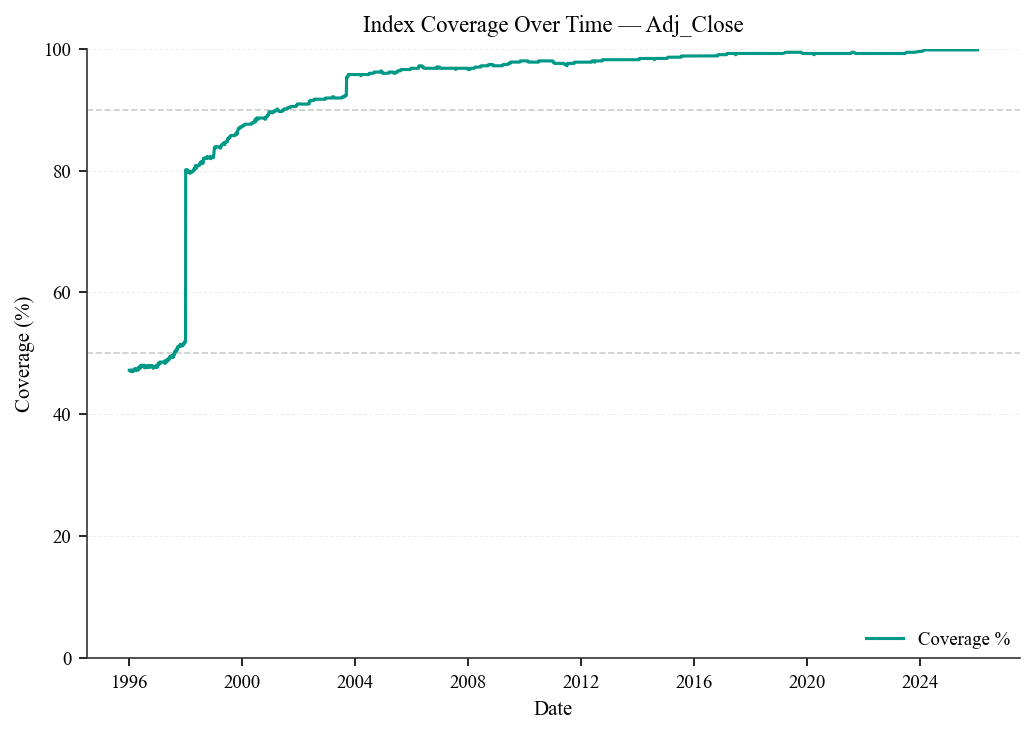

Missing ticker coverage periods:
- AAL:
  missing from 1996-01-02 to 1997-01-13
- AAMRQ:
  missing from 1996-01-02 to 2003-03-10
- ABI:
  missing from 1996-01-02 to 1997-12-29
  missing from 2008-11-18 to 2008-11-20
- ABKFQ:
  missing from 2000-12-11 to 2008-06-10
- ABS:
  missing from 1996-01-02 to 1997-12-29
- ABX:
  missing from 1996-01-02 to 2002-07-18
- ACKH:
  missing from 1996-01-02 to 1997-12-29
- ACV:
  missing from 1996-01-02 to 2006-11-16
- ADCT:
  missing from 1999-08-02 to 2003-09-08
  missing from 2005-05-13 to 2005-06-06
- AET:
  missing from 1996-01-02 to 1997-12-29
- AFS.A:
  missing from 1998-04-08 to 2000-11-29
- AGC:
  missing from 1996-01-02 to 2001-03-22
- AHM:
  missing from 1996-01-02 to 1997-12-29
- AL:
  missing from 1996-01-02 to 2002-07-18
- AM:
  missing from 1996-01-02 to 1997-12-29
- AMH:
  missing from 1996-01-02 to 1997-09-08
- AMP:
  missing from 1996-01-02 to 1999-03-30
- ANDW:
  missing from 1996-01-02 to 1997-12-29
- ANRZQ:
  missing from 2011-06-02

In [8]:
sp500_components: pd.DataFrame = dataset.SP500.load_historical()
merged_data: dict[str, pd.DataFrame] = features.load_merged_data()
coverage: pd.DataFrame = plots.coverage_over_time(
    price_data=merged_data,
    components=sp500_components,
    save_figures=False
)
missing_tickers: pd.DataFrame = pd.read_csv("../data/processed/missing_ticker.csv", index_col=0, parse_dates=True)
benchmark_df: pd.DataFrame = pd.read_csv("../data/processed/benchmark_2026-04-19.csv", index_col=0, parse_dates=True)

## Model losowy

In [9]:
modeling.select_random(sp500_components, n=10, coverage=coverage, date="2001-01-01")

{'tickers': ['NWL',
  'BCR',
  'ADI',
  'RF',
  'DG',
  'CSX',
  'CNXT',
  'BMET',
  'RDC',
  'BAX'],
 'difference': 1}

In [10]:
selected_components = modeling.select_random_periodic(
    components=sp500_components,
    n=10, 
    start_date="2000-01-01",
    frequency="quarterly",
    coverage=coverage
)
plots.summarize_df(selected_components)

DataFrame summary:
<class 'pandas.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        105 non-null    datetime64[us]
 1   tickers     105 non-null    object        
 2   difference  105 non-null    int64         
dtypes: datetime64[us](1), int64(1), object(1)
memory usage: 2.6+ KB
None


,date,difference
count,105,105.00000000
mean,2012-12-30 20:48:00,0.14285714
min,2000-01-01 00:00:00,0.00000000
25%,2006-07-01 00:00:00,0.00000000
50%,2013-01-01 00:00:00,0.00000000
75%,2019-07-01 00:00:00,0.00000000
max,2026-01-01 00:00:00,1.00000000
std,NaN,0.35160542


,date,tickers,difference
0,2000-01-01,"[OK, BEAM, ADM, RML, DLX, CTX, COP, BMY, RIG, ...",1
1,2000-04-01,"[PFE, RML, UNP, MDT, AXP, NAV, HPC, AEP, AEE, BA]",1
103,2025-10-01,"[BG, LULU, WFC, CRL, IDXX, PAYC, DELL, RF, FIS...",0
104,2026-01-01,"[MNST, WY, PSX, PHM, BF.B, ROST, STT, CDNS, EL...",0


In [11]:
import importlib
importlib.reload(modeling)

<module 'modeling' from '/home/michael/Documents/University/Semestr 4/Projekt indywidualny/Repo/src/modeling.py'>

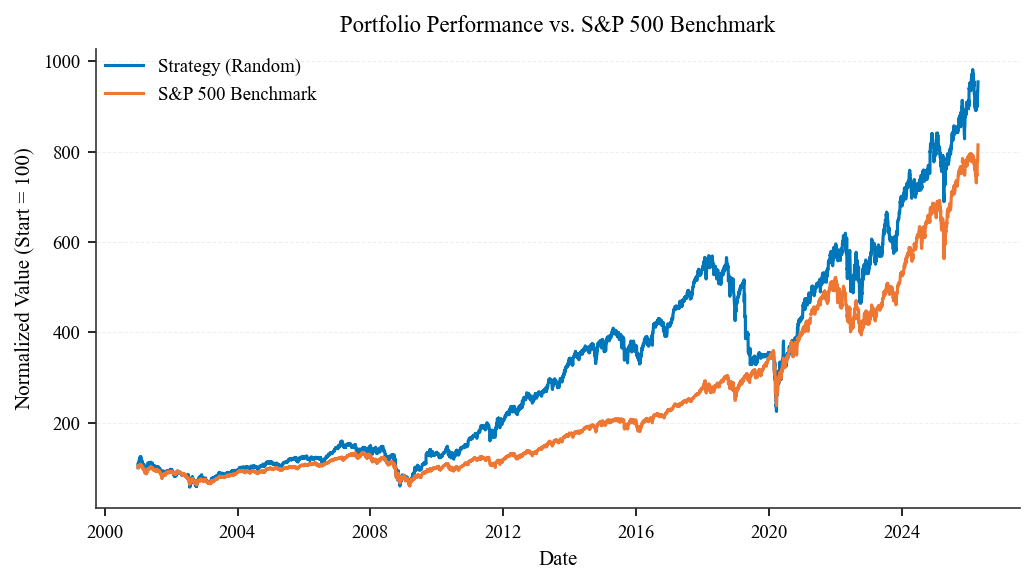

,Strategy (Random),S&P 500 Benchmark
Date,,
2001-01-02,100.00000000,100.00000000
2001-01-03,110.15313163,105.02137510
2001-01-04,109.02024423,103.91462970
2001-01-05,105.64011519,101.18692175
2001-01-08,105.73596322,101.01253978
...,...,...
2026-04-13,927.31556826,778.63843905
2026-04-14,933.64740230,793.51742181
2026-04-15,939.72332966,798.58685969


In [12]:
portfolio_value = modeling.backtest_portfolio(
    selected_companies=selected_components, 
    price_data=merged_data,
    start_date="2001-01-01",
    coverage=coverage,
    missing_ticker=missing_tickers,
    max_abs_return=2.0,
)

plots.YahooFinance.compare_tickers(
    dfs={
        "Strategy (Random)": portfolio_value,
        "S&P 500 Benchmark": benchmark_df
    },
    title="Portfolio Performance vs. S&P 500 Benchmark"
)